In [1]:
# Martin MacDonald
# Honours Project
# 2D Discrete Traffic Model

In [46]:
#Imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from queue import PriorityQueue

In [47]:
####
#Setup the grid
####

In [76]:
#Setup grid.
rows = 30
columns = 30
total_size = rows * columns
grid = np.zeros((rows, columns), dtype=np.int16)

#Add randomly generated cars to test.
num_cars = 5

#Ensure there are not more cars than the total size of the grid, throw a value error if there are.
if num_cars > total_size:
    raise ValueError("There are too many cars for the size of the grid")

#Define the Car class, used to hold data about each car.
class Car:
    def __init__(self, car_id, position, goal):
        self.id = car_id
        self.position = position
        self.goal = goal
        self.path = []
        self.wait_counter = 0
        self.total_distance_travelled = 0
        self.steps_taken = 0
        self.reached_goal = False

#Cars dictionary which holds each car, its ID, positon & goal.
cars = {}

#Generates a randomly positioned car, checks if that space is already occupied, if it is, try again, 
#if not, add car to grid & dictionary and give it a unique ID.
car_id = 1
while car_id <= num_cars:
    #Generate random position
    row = np.random.randint(0, rows)
    col = np.random.randint(0, columns)
    #Check if the car can spawn on unoccupied space.
    if grid[row, col] == 0:
        #If the space is clear, add that car to cars dictionary & grid and increment car_id by 1.
        grid[row, col] = car_id
        goal_row = np.random.randint(0, rows)
        goal_column = np.random.randint(0, columns)
        cars[car_id] = Car(car_id, (row, col), (goal_row, goal_column))
        car_id += 1

In [77]:
#### 
#Heuristic
####

In [78]:
#Manhattan Distance
def manhattan_distance(position_1, position_2):
    return (abs(position_1[0] - position_2[0]) + abs(position_1[1] - position_2[1]))

In [79]:
#Get neighbours for a given position.
def get_neighbours(position, rows, columns):
    #Get the current cars position and split it into row and column.
    row, column = position
    #Setup a list to contain neighbours.
    neighbours = []

    #Create a list of tuples which represent each cardinal direction/possible move
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    #For each direction, get the new position when taking that direction into account. 
    #If that position would be off the side of the grid, don't append it to the neighbours list.
    for delta_row, delta_column in directions:
        new_row, new_column = row + delta_row, column + delta_column

        if 0 <= new_row < rows and 0 <= new_column < columns:
            neighbours.append((new_row, new_column))

    #Return all the valid neighbours of the current car. 
    return neighbours

In [80]:
#Reconstruct the path from start to goal using came_from.
def reconstruct_path(came_from, start, goal):
    #Set the current position to goal.
    current = goal
    #Setup a list to contain the path.
    path = []

    #While current has not reached the start, add the current step to the path 
    #then set current to its parent step (the next step along on the way to start).
    while current != start:
        path.append(current)
        current = came_from[current]

    #Add the start to the path.
    path.append(start)
    #Reverse the path list so it can be followed along as start -> goal, rather than goal -> start which it was.
    path.reverse()
    #Return the newly created path.
    return path

In [81]:
#A Star algorithm
def a_star(grid, start, goal, rows, columns, car_id):
    #Setup the frontier as a priority queue. A priority queue is a queue where each item 
    #in the queue can be given a different priority, meaning that higher priority items are 
    #dequeued first.
    frontier = PriorityQueue()
    #Add the start to the queue, give it a priority of 0.
    frontier.put((0, start))

    #Setup dictionaries to contain came from and cost so far.
    came_from = {}
    cost_so_far = {}

    #Initialise their start position to be none (no parent yet) and 0 (no cost yet).
    came_from[start] = None
    cost_so_far[start] = 0

    #While the frontier is not empty, continue to search.
    while not frontier.empty():
        #Only get the current value from the queue, as we don't need the priority value, discard it.
        _, current = frontier.get()

        #Check if the goal has been reached.
        if current == goal:
            return reconstruct_path(came_from, start, goal)

        #Explore each valid neighbour of the current position of the frontier.
        for neighbour in get_neighbours(current, rows, columns):
            #Skip if the neighbour is occupied by a car or obstacle, unless it's the goal.
            if grid[neighbour[0], neighbour[1]] != 0 and grid[neighbour[0], neighbour[1]] != car_id and neighbour != goal:
                continue

            #Calculate the new cost, each move costs 1.
            new_cost = cost_so_far[current] + 1

            #If this is a new position or a cheaper path to this position has been found, update the frontier. 
            if neighbour not in cost_so_far or new_cost < cost_so_far[neighbour]:
                cost_so_far[neighbour] = new_cost
                #The priority is the actual cost added to the estimated cost to the goal.
                priority = new_cost + manhattan_distance(neighbour, goal)
                frontier.put((priority, neighbour))
                came_from[neighbour] = current
    #Return an empty list if no path could be found.
    return []

In [82]:
#Small test for A* algorithm.
path = a_star(grid, (5, 5), (25, 25), rows, columns, car_id = 1)

if path:
    print(f"Path found with {len(path) - 1} moves.")
    print(f"Path found with {len(path)} positions.")
    print(path)
else:
    print("No path found.")

Path found with 40 moves.
Path found with 41 positions.
[(5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10), (5, 11), (5, 12), (5, 13), (5, 14), (5, 15), (5, 16), (5, 17), (5, 18), (5, 19), (5, 20), (5, 21), (5, 22), (5, 23), (5, 24), (6, 24), (7, 24), (8, 24), (9, 24), (10, 24), (11, 24), (12, 24), (13, 24), (14, 24), (15, 24), (16, 24), (17, 24), (18, 24), (19, 24), (20, 24), (21, 24), (21, 25), (22, 25), (23, 25), (24, 25), (25, 25)]


In [83]:
def update_simulation(grid, cars, rows, columns, max_wait = 3):

    for car in cars.values():
        #If car has reached goal, skip onto the next car.
        if car.reached_goal:
            continue

        #If the car doesn't have a path, give it one using a*.
        if not car.path:
            car.path = a_star(grid, car.position, car.goal, rows, columns, car.id)
            
        if len(car.path) > 1:
            next_position = car.path[1]
    
            if grid[next_position[0], next_position[1]] == 0:
                grid[car.position[0], car.position[1]] = 0
                car.position = next_position
                grid[next_position[0], next_position[1]] = car.id
                car.path.pop(0)
                car.wait_counter = 0
                car.total_distance_travelled += 1
                car.steps_taken += 1
    
                if car.position == car.goal:
                    print(f"Car {car.id} has reached goal.")
                    car.reached_goal = True
    
            else:
                car.wait_counter += 1
    
                if car.wait_counter >= max_wait:
                    print(f"Car {car.id} replanning route after waiting {car.wait_counter} steps.")
                    car.path = a_star(grid, car.position, car.goal, rows, columns, car.id)
                    car.wait_counter = 0

In [84]:
for time in range(100):
    update_simulation(grid, cars, rows, columns, 3)

Car 2 has reached goal.
Car 3 has reached goal.
Car 5 has reached goal.
Car 1 has reached goal.
Car 4 has reached goal.


In [10]:
####
#Draw canvas
####

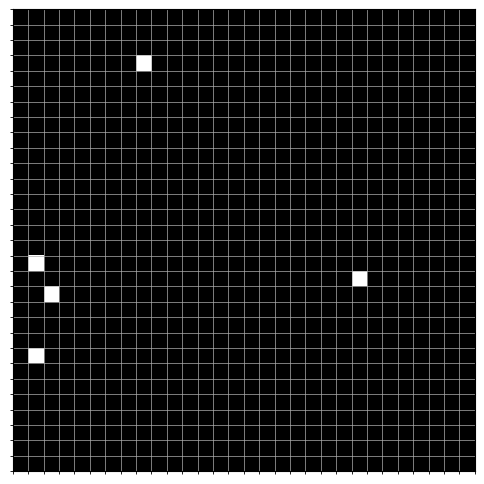

In [11]:
#Create the canvas for the grid.
plt.figure(figsize=(6, 6))
#Draw the grid.
plt.imshow(grid, cmap='gray', vmin=0, vmax=1, aspect='equal')

#Draw gridlines, makes it easier to see positions.
plt.gca().set_xticks(np.arange(-0.5, columns, 1), minor=True)
plt.gca().set_yticks(np.arange(-0.5, rows, 1), minor=True)
plt.grid(which='minor', linewidth=0.5)

# Remove labelling, disable this code to see them again.
plt.xticks([])
plt.yticks([])

#Display the grid.
plt.show()